In [1]:
import tarfile
import requests
import os
from collections import defaultdict
import matplotlib.pyplot as plt
from pathlib import Path
import requests
from tqdm import tqdm
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torch.nn as nn
from torchvision.models import vit_b_16, ViT_B_16_Weights
import torch
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score
import time
from pathlib import Path
from sklearn.model_selection import train_test_split
import shutil
import pandas as pd
from collections import Counter

In [2]:
KAGGLE_INPUT_ROOT = Path("/kaggle/input/datasets/quan0207/indoor-scene/indoorCVPR_09")
KAGGLE_WORKING_ROOT = Path("/kaggle/working")

print("Input exists:", KAGGLE_INPUT_ROOT.exists())
print("Working exists:", KAGGLE_WORKING_ROOT.exists())
print("Input folders:", [p.name for p in KAGGLE_INPUT_ROOT.iterdir()][:10])

Input exists: True
Working exists: True
Input folders: ['Images']


In [3]:
src_root = KAGGLE_INPUT_ROOT / "Images"
print(src_root.exists())

True


In [4]:
image_exts = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")

count = 0
for root, dirs, files in os.walk(KAGGLE_INPUT_ROOT):
    count += sum(1 for f in files if f.lower().endswith(image_exts))

print("Total images:", count)

Total images: 15620


Class number: 67
Total images: 15620
Class has least images: 101
Class has most images: 734
Average: 233.13432835820896

Example:
airport_inside: 608
artstudio: 140
auditorium: 176
bakery: 405
bar: 604
bathroom: 197
bedroom: 662
bookstore: 380
bowling: 213
buffet: 111


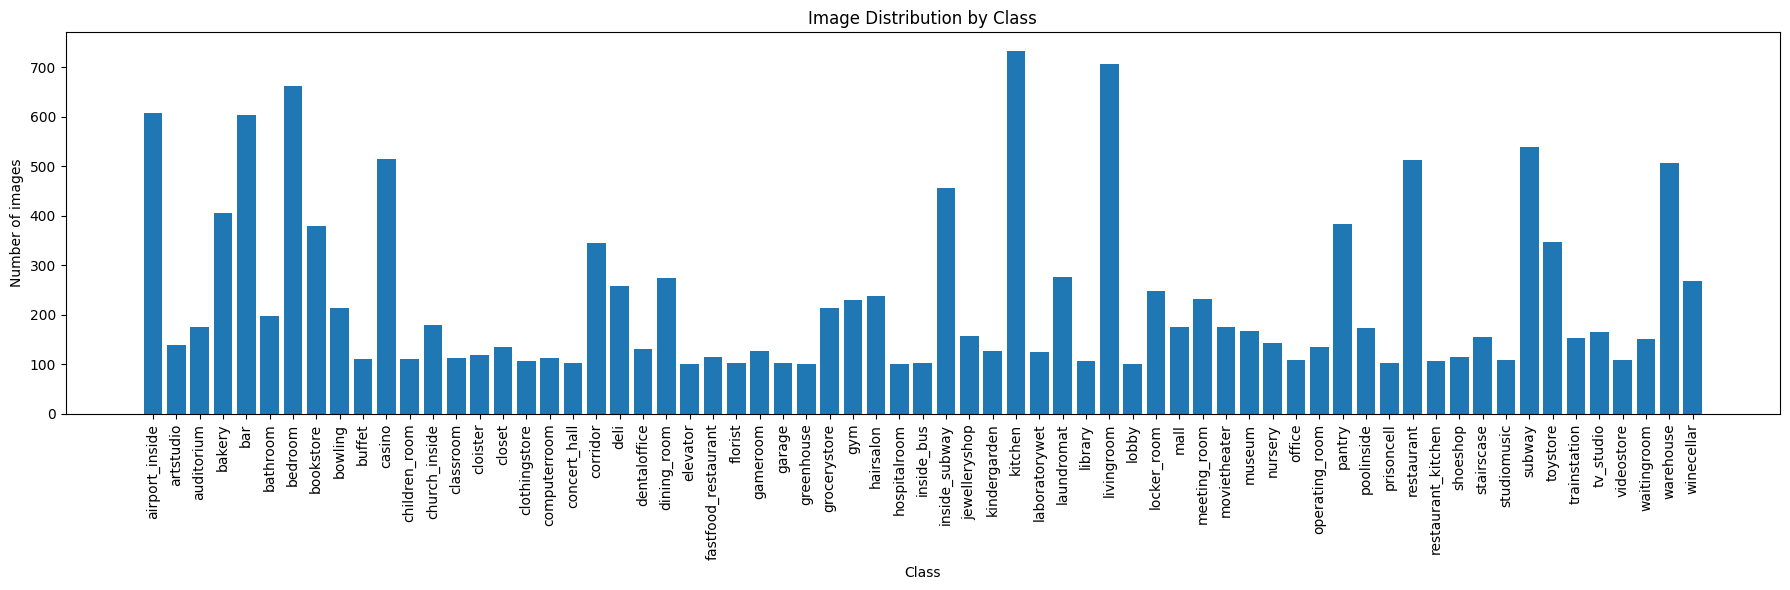

In [5]:
image_exts = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")

class_counts = {}

for class_name in sorted(os.listdir(src_root)):
    class_path = os.path.join(src_root, class_name)
    if os.path.isdir(class_path):
        count = sum(
            1 for f in os.listdir(class_path)
            if f.lower().endswith(image_exts)
        )
        class_counts[class_name] = count

# In thống kê cơ bản
counts = list(class_counts.values())
print("Class number:", len(class_counts))
print("Total images:", sum(counts))
print("Class has least images:", min(counts))
print("Class has most images:", max(counts))
print("Average:", sum(counts) / len(counts))

# In vài class đầu
print("\nExample:")
for k, v in list(class_counts.items())[:10]:
    print(f"{k}: {v}")

# Vẽ biểu đồ distribution
plt.figure(figsize=(18, 6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.ylabel("Number of images")
plt.xlabel("Class")
plt.title("Image Distribution by Class")
plt.tight_layout()
plt.show()

In [6]:
WORKING_ROOT = Path("/kaggle/working")
dst_root = WORKING_ROOT / "mit_indoor_split"
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

paths = []
labels = []

for class_dir in sorted(src_root.iterdir()):
    if class_dir.is_dir():
        for img_path in class_dir.iterdir():
            if img_path.suffix.lower() in image_exts:
                paths.append(img_path)
                labels.append(class_dir.name)

# 70 train, 30 temp
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths, labels,
    test_size=0.3,
    stratify=labels,
    random_state=42
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=2/3,
    stratify=temp_labels,
    random_state=42
)

def copy_split(file_paths, file_labels, split_name):
    for path, label in zip(file_paths, file_labels):
        out_dir = dst_root / split_name / label
        out_dir.mkdir(parents=True, exist_ok=True)
        shutil.copy2(path, out_dir / path.name)

copy_split(train_paths, train_labels, "train")
copy_split(val_paths, val_labels, "val")
copy_split(test_paths, test_labels, "test")

print("Done.")
print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

Done.
Train: 10934
Val: 1562
Test: 3124


In [7]:
root = Path("mit_indoor_split")

for split in ["train", "val", "test"]:
    split_dir = root / split
    classes = [d.name for d in split_dir.iterdir() if d.is_dir()]
    print(split, "num_classes =", len(classes))
    print("sample classes:", classes[:5])

train num_classes = 67
sample classes: ['hospitalroom', 'hairsalon', 'toystore', 'kindergarden', 'bedroom']
val num_classes = 67
sample classes: ['hospitalroom', 'hairsalon', 'toystore', 'kindergarden', 'bedroom']
test num_classes = 67
sample classes: ['hospitalroom', 'hairsalon', 'toystore', 'kindergarden', 'bedroom']


# Transform with no augmentation

In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def get_transforms(use_aug=False):
    base_tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    if use_aug:
        aug_tf = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    else:
        aug_tf = base_tf

    test_tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    return base_tf, aug_tf, test_tf

In [9]:
class ClassAwareAugImageFolder(ImageFolder):
    def __init__(self, root, minority_classes, base_transform, minority_transform):
        super().__init__(root=root, transform=None)
        self.minority_classes = set(minority_classes)
        self.base_transform = base_transform
        self.minority_transform = minority_transform

    def __getitem__(self, index):
        path, target = self.samples[index]
        sample = self.loader(path)

        if target in self.minority_classes:
            
            sample = self.minority_transform(sample)
        else:
            sample = self.base_transform(sample)

        return sample, target

In [10]:
def get_dataloaders(
    data_root,
    batch_size=32,
    use_aug=False,
    class_aware_aug=False,
    num_workers=2
):
    base_tf, aug_tf, test_tf = get_transforms(use_aug=use_aug)
    temp_train_ds = ImageFolder(f"{data_root}/train", transform=base_tf)

    minority_classes = set()
    if class_aware_aug:
        label_counts = Counter(label for _, label in temp_train_ds.samples)
        mean_count = sum(label_counts.values()) / len(label_counts)
        minority_classes = {
            cls_idx for cls_idx, count in label_counts.items()
            if count < mean_count
        }

        train_ds = ClassAwareAugImageFolder(
            root=f"{data_root}/train",
            minority_classes=minority_classes,
            base_transform=base_tf,
            minority_transform=aug_tf
        )
    else:
        train_transform = aug_tf if use_aug else base_tf
        train_ds = ImageFolder(f"{data_root}/train", transform=train_transform)

    val_ds = ImageFolder(f"{data_root}/val", transform=test_tf)
    test_ds = ImageFolder(f"{data_root}/test", transform=test_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader, minority_classes

### Model

In [11]:
def build_vit(num_classes, device, freeze_backbone=True):
    model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, num_classes)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
        for param in model.heads.parameters():
            param.requires_grad = True
    else: 
        for param in model.parameters():
            param.requires_grad = True
    
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print("Trainable params:", trainable)
    print("Total params:", total)
    return model.to(device)

In [12]:
class EarlyStopping:
    def __init__(self, patience=5, mode="max", min_delta=0.0, save_path="best_model.pth"):
        self.patience = patience
        self.mode = mode          # "max" for accuracy/F1, "min" for loss
        self.min_delta = min_delta
        self.save_path = save_path

        self.best_score = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score = score
            torch.save(model.state_dict(), self.save_path)
            return

        if self.mode == "max":
            improved = score > self.best_score + self.min_delta
        else:
            improved = score < self.best_score - self.min_delta

        if improved:
            self.best_score = score
            self.counter = 0
            torch.save(model.state_dict(), self.save_path)
        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

In [13]:
def build_layerwise_lr_optimizer(model, head_lr=3e-4, layer_decay=0.8, weight_decay=0.05):
    param_groups = []

    blocks = list(model.encoder.layers)
    n_blocks = len(blocks)

    # conv / patch embedding
    param_groups.append({
        "params": model.conv_proj.parameters(),
        "lr": head_lr * (layer_decay ** (n_blocks + 1))
    })

    # transformer encoder blocks
    for i, block in enumerate(blocks):
        depth_from_head = n_blocks - 1 - i
        lr = head_lr * (layer_decay ** (depth_from_head + 1))
        param_groups.append({
            "params": block.parameters(),
            "lr": lr
        })

    # final layer norm
    param_groups.append({
        "params": model.encoder.ln.parameters(),
        "lr": head_lr * layer_decay
    })

    # classifier head
    param_groups.append({
        "params": model.heads.parameters(),
        "lr": head_lr
    })

    return optim.AdamW(param_groups, weight_decay=weight_decay)

In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for batch_idx, (images, labels) in enumerate(loader, start=1):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        if hasattr(loader, "set_postfix"):
            loader.set_postfix(
                loss=f"{loss.item():.4f}",
                avg_loss=f"{running_loss / batch_idx:.4f}"
            )

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    return epoch_loss, epoch_acc, epoch_f1


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    return epoch_loss, epoch_acc, epoch_f1, all_labels, all_preds

In [15]:
def run_experiment(
    exp_name,
    data_root,
    device,
    batch_size=32,
    num_epochs=10,
    use_aug=False,
    freeze_backbone=True,
    class_aware_aug=False,
    optimizer_mode="freeze",
):
    data_root = Path(data_root)

    save_dir = Path("/kaggle/working/models")
    save_dir.mkdir(parents=True, exist_ok=True)

    save_path = save_dir / f"{exp_name}_best.pth"

    print(f"Experiment: {exp_name}")
    print(f"Data root : {data_root.resolve() if data_root.exists() else data_root}")
    print(f"Save path : {save_path}")
    print(f"Optimizer mode: {optimizer_mode}")
    train_ds, val_ds, test_ds, train_loader, val_loader, test_loader, minority_classes = get_dataloaders(
        data_root=data_root,
        batch_size=batch_size,
        use_aug=use_aug,
        class_aware_aug=class_aware_aug
    )

    model = build_vit(
        num_classes=len(train_ds.classes),
        device=device,
        freeze_backbone=freeze_backbone
    )

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # optimizer = optim.AdamW(
    #     model.heads.parameters() if freeze_backbone else model.parameters(),
    #     lr=1e-3 if freeze_backbone else 1e-4,
    #     weight_decay=1e-4
    # )
    if optimizer_mode == "freeze":
        optimizer = optim.AdamW(
            model.heads.parameters(),
            lr=1e-3,
            weight_decay=1e-4
        )

    elif optimizer_mode == "full":
        optimizer = optim.AdamW(
            model.parameters(),
            lr=3e-5,
            weight_decay=0.05
        )

    elif optimizer_mode == "layerwise":
        optimizer = build_layerwise_lr_optimizer(
            model,
            head_lr=3e-4,
            layer_decay=0.8,
            weight_decay=0.05
        )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=num_epochs,
        eta_min=1e-6
    )

    early_stopper = EarlyStopping(
        patience=5,
        mode="max",
        min_delta=1e-4,
        save_path=str(save_path)
    )

    history = {
        "train_loss": [], "train_acc": [], "train_f1": [],
        "val_loss": [], "val_acc": [], "val_f1": []
    }

    for epoch in range(num_epochs):
        start = time.time()

        train_loss, train_acc, train_f1 = train_one_epoch(
            model, tqdm(train_loader, desc=f"{exp_name} Train {epoch+1}/{num_epochs}"),
            criterion, optimizer, device
        )
        val_loss, val_acc, val_f1, _, _ = evaluate(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        elapsed = time.time() - start
        print(
            f"[{exp_name}] Epoch {epoch+1}/{num_epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} train_f1={train_f1:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f} | "
            f"time={elapsed:.1f}s"
        )

        early_stopper(val_acc, model)
        scheduler.step()
        
        if early_stopper.early_stop:
            print(f"[{exp_name}] Early stopping triggered.")
            break
    if save_path.exists():
        model.load_state_dict(torch.load(save_path, map_location=device))
        print(f"[{exp_name}] Loaded best model from: {save_path}")
    else:
        print(f"[{exp_name}] Warning: best model file not found at {save_path}")
    test_loss, test_acc, test_f1, y_true, y_pred = evaluate(model, test_loader, criterion, device)

    return {
        "exp_name": exp_name,
        "use_aug": use_aug,
        "class_aware_aug": class_aware_aug,
        "freeze_backbone": freeze_backbone,
        "optimizer_mode": optimizer_mode,
        "minority_classes": minority_classes,
        "model_path": str(save_path),
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "history": history,
        "y_true": y_true,
        "y_pred": y_pred,
        "classes": train_ds.classes
    }

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = []
result_noaug = run_experiment(
    exp_name="vit_freeze_noaug",
    data_root=dst_root,
    device=device,
    batch_size=32,
    num_epochs=20,
    use_aug=False,
    freeze_backbone=True,
    class_aware_aug=False,
    optimizer_mode="freeze",
)
results.append(result_noaug)

Experiment: vit_freeze_noaug
Data root : /kaggle/working/mit_indoor_split
Save path : /kaggle/working/models/vit_freeze_noaug_best.pth
Optimizer mode: freeze
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 190MB/s]


Trainable params: 51523
Total params: 85850179


vit_freeze_noaug Train 1/20: 100%|██████████| 342/342 [02:39<00:00,  2.14it/s, avg_loss=1.7899, loss=1.8170]


[vit_freeze_noaug] Epoch 1/20 | train_loss=1.7899 train_acc=0.6937 train_f1=0.6524 | val_loss=1.4509 val_acc=0.7708 val_f1=0.7389 | time=180.0s


...

[vit_freeze_noaug] Epoch 12/20 | train_loss=0.9773 train_acc=0.9706 train_f1=0.9768 | val_loss=1.4043 val_acc=0.7951 val_f1=0.7831 | time=192.7s
EarlyStopping counter: 3/5


vit_freeze_noaug Train 13/20: 100%|██████████| 342/342 [02:53<00:00,  1.98it/s, avg_loss=0.9684, loss=0.9923]


[vit_freeze_noaug] Epoch 13/20 | train_loss=0.9684 train_acc=0.9739 train_f1=0.9797 | val_loss=1.4070 val_acc=0.7919 val_f1=0.7798 | time=193.7s
EarlyStopping counter: 4/5


vit_freeze_noaug Train 14/20: 100%|██████████| 342/342 [02:52<00:00,  1.98it/s, avg_loss=0.9620, loss=1.0478]


[vit_freeze_noaug] Epoch 14/20 | train_loss=0.9620 train_acc=0.9758 train_f1=0.9813 | val_loss=1.4110 val_acc=0.7945 val_f1=0.7814 | time=192.8s
EarlyStopping counter: 5/5
[vit_freeze_noaug] Early stopping triggered.
[vit_freeze_noaug] Loaded best model from: /kaggle/working/models/vit_freeze_noaug_best.pth


In [17]:
result_freeze_aug = run_experiment(
    exp_name="vit_freeze_aug",
    data_root=dst_root,
    device=device,
    batch_size=32,
    num_epochs=20,
    use_aug=True,
    freeze_backbone=True,
    class_aware_aug=False,
    optimizer_mode="freeze",
)
results.append(result_freeze_aug)

Experiment: vit_freeze_aug
Data root : /kaggle/working/mit_indoor_split
Save path : /kaggle/working/models/vit_freeze_aug_best.pth
Optimizer mode: freeze
Trainable params: 51523
Total params: 85850179


vit_freeze_aug Train 1/20: 100%|██████████| 342/342 [02:52<00:00,  1.98it/s, avg_loss=1.8699, loss=1.4217]


[vit_freeze_aug] Epoch 1/20 | train_loss=1.8699 train_acc=0.6649 train_f1=0.6245 | val_loss=1.4820 val_acc=0.7612 val_f1=0.7257 | time=193.2s


vit_freeze_aug Train 2/20: 100%|██████████| 342/342 [02:52<00:00,  1.99it/s, avg_loss=1.4089, loss=1.2942]


[vit_freeze_aug] Epoch 2/20 | train_loss=1.4089 train_acc=0.7896 train_f1=0.7730 | val_loss=1.4225 val_acc=0.7766 val_f1=0.7528 | time=192.5s


...

[vit_freeze_aug] Epoch 18/20 | train_loss=1.0508 train_acc=0.9416 train_f1=0.9495 | val_loss=1.3947 val_acc=0.8015 val_f1=0.7915 | time=194.2s
EarlyStopping counter: 2/5


vit_freeze_aug Train 19/20: 100%|██████████| 342/342 [02:53<00:00,  1.97it/s, avg_loss=1.0460, loss=1.0003]


[vit_freeze_aug] Epoch 19/20 | train_loss=1.0460 train_acc=0.9441 train_f1=0.9507 | val_loss=1.3941 val_acc=0.8009 val_f1=0.7890 | time=193.9s
EarlyStopping counter: 3/5


vit_freeze_aug Train 20/20: 100%|██████████| 342/342 [02:51<00:00,  1.99it/s, avg_loss=1.0470, loss=0.9661]


[vit_freeze_aug] Epoch 20/20 | train_loss=1.0470 train_acc=0.9427 train_f1=0.9502 | val_loss=1.3941 val_acc=0.8015 val_f1=0.7899 | time=192.1s
EarlyStopping counter: 4/5
[vit_freeze_aug] Loaded best model from: /kaggle/working/models/vit_freeze_aug_best.pth


In [18]:
result_full = run_experiment(
    exp_name="vit_full_aug",
    data_root=dst_root,
    device=device,
    batch_size=32,
    num_epochs=20,
    use_aug=True,
    freeze_backbone=False,
    class_aware_aug=False,
    optimizer_mode="full",
)
results.append(result_full)

Experiment: vit_full_aug
Data root : /kaggle/working/mit_indoor_split
Save path : /kaggle/working/models/vit_full_aug_best.pth
Optimizer mode: full
Trainable params: 85850179
Total params: 85850179


vit_full_aug Train 1/20: 100%|██████████| 342/342 [07:15<00:00,  1.27s/it, avg_loss=2.2676, loss=1.6222]


[vit_full_aug] Epoch 1/20 | train_loss=2.2676 train_acc=0.5658 train_f1=0.4683 | val_loss=1.6110 val_acc=0.7196 val_f1=0.6726 | time=456.5s


vit_full_aug Train 2/20: 100%|██████████| 342/342 [07:17<00:00,  1.28s/it, avg_loss=1.3503, loss=1.2484]


[vit_full_aug] Epoch 2/20 | train_loss=1.3503 train_acc=0.8089 train_f1=0.7749 | val_loss=1.3993 val_acc=0.7740 val_f1=0.7490 | time=457.5s


...

[vit_full_aug] Epoch 15/20 | train_loss=0.7504 train_acc=0.9980 train_f1=0.9977 | val_loss=1.3309 val_acc=0.8118 val_f1=0.7955 | time=456.7s
EarlyStopping counter: 3/5


vit_full_aug Train 16/20: 100%|██████████| 342/342 [07:15<00:00,  1.27s/it, avg_loss=0.7496, loss=0.7462]


[vit_full_aug] Epoch 16/20 | train_loss=0.7496 train_acc=0.9978 train_f1=0.9975 | val_loss=1.3265 val_acc=0.8169 val_f1=0.8058 | time=456.5s
EarlyStopping counter: 4/5


vit_full_aug Train 17/20: 100%|██████████| 342/342 [07:16<00:00,  1.28s/it, avg_loss=0.7480, loss=0.7449]


[vit_full_aug] Epoch 17/20 | train_loss=0.7480 train_acc=0.9981 train_f1=0.9979 | val_loss=1.3360 val_acc=0.8118 val_f1=0.7978 | time=457.0s
EarlyStopping counter: 5/5
[vit_full_aug] Early stopping triggered.
[vit_full_aug] Loaded best model from: /kaggle/working/models/vit_full_aug_best.pth


In [19]:
result_layerwise_aug = run_experiment(
    exp_name="vit_layerwise_aug",
    data_root=dst_root,
    device=device,
    batch_size=32,
    num_epochs=20,
    use_aug=True,
    freeze_backbone=False,
    class_aware_aug=False,
    optimizer_mode="layerwise",
)
results.append(result_layerwise_aug)

Experiment: vit_layerwise_aug
Data root : /kaggle/working/mit_indoor_split
Save path : /kaggle/working/models/vit_layerwise_aug_best.pth
Optimizer mode: layerwise
Trainable params: 85850179
Total params: 85850179


vit_layerwise_aug Train 1/20: 100%|██████████| 342/342 [07:17<00:00,  1.28s/it, avg_loss=1.7509, loss=1.4816]


[vit_layerwise_aug] Epoch 1/20 | train_loss=1.7509 train_acc=0.6709 train_f1=0.6213 | val_loss=1.4299 val_acc=0.7798 val_f1=0.7664 | time=457.6s


vit_layerwise_aug Train 2/20: 100%|██████████| 342/342 [07:16<00:00,  1.28s/it, avg_loss=1.1652, loss=0.9575]


[vit_layerwise_aug] Epoch 2/20 | train_loss=1.1652 train_acc=0.8581 train_f1=0.8373 | val_loss=1.4281 val_acc=0.7522 val_f1=0.7379 | time=456.7s
EarlyStopping counter: 1/5


...

[vit_layerwise_aug] Epoch 13/20 | train_loss=0.7478 train_acc=0.9970 train_f1=0.9966 | val_loss=1.4076 val_acc=0.7964 val_f1=0.7810 | time=456.0s
EarlyStopping counter: 3/5


vit_layerwise_aug Train 14/20: 100%|██████████| 342/342 [07:16<00:00,  1.28s/it, avg_loss=0.7459, loss=0.7410]


[vit_layerwise_aug] Epoch 14/20 | train_loss=0.7459 train_acc=0.9965 train_f1=0.9962 | val_loss=1.3733 val_acc=0.8124 val_f1=0.8055 | time=457.4s
EarlyStopping counter: 4/5


vit_layerwise_aug Train 15/20: 100%|██████████| 342/342 [07:15<00:00,  1.27s/it, avg_loss=0.7430, loss=0.7385]


[vit_layerwise_aug] Epoch 15/20 | train_loss=0.7430 train_acc=0.9977 train_f1=0.9977 | val_loss=1.3691 val_acc=0.8188 val_f1=0.8165 | time=456.2s
EarlyStopping counter: 5/5
[vit_layerwise_aug] Early stopping triggered.
[vit_layerwise_aug] Loaded best model from: /kaggle/working/models/vit_layerwise_aug_best.pth


In [20]:
print("No Aug  | Test Acc:", result_noaug["test_acc"], "| Test F1:", result_noaug["test_f1"])
print("With Aug| Test Acc:", result_freeze_aug["test_acc"],   "| Test F1:", result_freeze_aug["test_f1"])
print("With Aug| Test Acc:", result_full["test_acc"],   "| Test F1:", result_full["test_f1"])
print("With Aug| Test Acc:", result_layerwise_aug["test_acc"],   "| Test F1:", result_layerwise_aug["test_f1"])

No Aug  | Test Acc: 0.793213828425096 | Test F1: 0.7820178600662593
With Aug| Test Acc: 0.793213828425096 | Test F1: 0.783213638577688
With Aug| Test Acc: 0.8249039692701664 | Test F1: 0.808924653491429
With Aug| Test Acc: 0.821382842509603 | Test F1: 0.8053866421778028


In [21]:
df = pd.DataFrame([
    {
        "Experiment": r["exp_name"],
        "Augmentation": r["use_aug"],
        "Freeze Backbone": r["freeze_backbone"],
        "Optimizer Mode": r["optimizer_mode"],
        "Test Loss": r["test_loss"],
        "Test Accuracy": r["test_acc"],
        "Test Macro F1": r["test_f1"],
    }
    for r in results
])

df = df.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)
df

,Experiment,Augmentation,Freeze Backbone,Optimizer Mode,Test Loss,Test Accuracy,Test Macro F1
0,vit_full_aug,True,False,full,1.302642,0.824904,0.808925
1,vit_layerwise_aug,True,False,layerwise,1.324290,0.821383,0.805387
2,vit_freeze_aug,True,True,freeze,1.387410,0.793214,0.783214
3,vit_freeze_noaug,False,True,freeze,1.398634,0.793214,0.782018


In [22]:
for r in results:
    print(r["exp_name"])
    print("Best val acc:", max(r["history"]["val_acc"]))
    print("Best val f1 :", max(r["history"]["val_f1"]))
    print("-" * 50)

vit_freeze_noaug
Best val acc: 0.8021766965428937
Best val f1 : 0.7903302758259967
--------------------------------------------------
vit_freeze_aug
Best val acc: 0.8034571062740077
Best val f1 : 0.7915306558962133
--------------------------------------------------
vit_full_aug
Best val acc: 0.8207426376440461
Best val f1 : 0.8082362816806177
--------------------------------------------------
vit_layerwise_aug
Best val acc: 0.8233034571062741
Best val f1 : 0.8204808130027708
--------------------------------------------------
